# Data Modeling

## 1. Setup

We have already completed the data cleaning and feature engineering steps, and now we are ready to move on to the modeling phase. In this section, we will set up our environment for modeling by installing necessary dependencies, loading the preprocessed data, and preparing it for training and testing.

By now, we have the `X_train`, `X_test`, `y_train`, and `y_test` datasets saved as CSV files in the `data` directory. We will load these datasets into our modeling environment and ensure that they are ready for use in training and evaluating our machine learning models.

For the models to be used, earlier EDA and feature engineering informed our choice of models. We will be using the following models for our analysis:
1. **Logistic Regression** - as the baseline model for regression tasks. It is perfect fit for binary classification tasks, as it is simple, interpretable, and efficient.
2. **LightGBM** - as the advanced model for regression tasks. It is a gradient boosting framework that uses tree-based learning algorithms, known for its speed and efficiency, especially with large datasets.

These two algorithms will be stacked to create a robust ensemble model that leverages the strengths of both approaches. The logistic regression will provide a solid baseline, while LightGBM will capture complex patterns in the data. The final ensemble model will be evaluated based on its performance on the test set using **ROC AUC** as the primary metric.

### 1.1 Install Dependencies

In [1]:
# Import modules
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Import machine learning libraries
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

Set up the working directory by setting the paths to the data, then **import the training & testing datasets**.

In [2]:
from pathlib import Path

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "output"

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")
y_test = pd.read_csv(DATA_DIR / "y_test.csv")

In [3]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   int64  
 4   Number vmail messages   2666 non-null   int64  
 5   Total day minutes       2666 non-null   float64
 6   Total day calls         2666 non-null   int64  
 7   Total eve minutes       2666 non-null   float64
 8   Total eve calls         2666 non-null   int64  
 9   Total night minutes     2666 non-null   float64
 10  Total night calls       2666 non-null   int64  
 11  Total intl minutes      2666 non-null   float64
 12  Total intl calls        2666 non-null   int64  
 13  Customer service calls  2666 non-null   int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 291.7

In [4]:
X_train.head()

,State,Account length,Area code,International plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls
0,KS,128,415,0,25,265.1,110,197.4,99,244.7,91,10.0,3,1
1,OH,107,415,0,26,161.6,123,195.5,103,254.4,103,13.7,3,1
2,NJ,137,415,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0
3,OH,84,408,1,0,299.4,71,61.9,88,196.9,89,6.6,7,2
4,OK,75,415,1,0,166.7,113,148.3,122,186.9,121,10.1,3,3


### 1.2 Methods for Categorical Variables

Because logistic regression is sensitive to the scale of the features, we will need to **standardize the features** using `StandardScaler`. This will ensure that all features have a mean of 0 and a standard deviation of 1, which can improve the performance of the logistic regression model. This step will only be applied to the input directed to the logistic regression model, while LightGBM can handle unscaled features.

In [5]:
def target_encode_state(X_tr, y_tr, X_other, col="State", smoothing=10):
    if hasattr(y_tr, "squeeze"):
        y_tr_1d = y_tr.squeeze()
    else:
        y_tr_1d = y_tr.ravel()
    
    global_mean = y_tr_1d.mean()

    tr_col = X_tr[col].astype(str)
    other_col = X_other[col].astype(str)
    
    # Build stats DataFrame using matching indexes
    df = pd.DataFrame({
        col: tr_col,
        "target": y_tr_1d
    })
    stats = df.groupby(col)["target"].agg(["mean", "count"])
    
    smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (
        stats["count"] + smoothing
    )
    
    tr_encoded = tr_col.map(smoothed).fillna(global_mean)
    other_encoded = other_col.map(smoothed).fillna(global_mean)
    
    return tr_encoded, other_encoded

In [6]:
def one_hot_area_code(X_tr, X_other):
    # One hot encodes the low-cardinality categorical variable `Area code`.
    
    tr_dummies = pd.get_dummies(X_tr['Area code'], prefix='Area_code', drop_first=True)
    other_dummies = pd.get_dummies(X_other['Area code'], prefix='Area_code', drop_first=True)
    other_dummies = other_dummies.reindex(columns=tr_dummies.columns, fill_value=0)
    
    X_tr_out = pd.concat([X_tr.drop(columns=['Area code']), tr_dummies], axis=1)
    X_other_out = pd.concat([X_other.drop(columns=['Area code']), other_dummies], axis=1)
    return X_tr_out, X_other_out

### 1.3 Model Training

In [7]:
N_FOLDS = 10 # more folds than default 5 to give more stable OOF predictions for stacking
categorical_features = ['State', 'Area code']

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

n_train = len(X_train)

# OOF predictions for stacking - this is to make sure that
# the predictions for the training set are not biased by being trained on the same data.
oof_lgb = np.zeros(n_train)
oof_lr = np.zeros(n_train)

for train_idx, val_idx in skf.split(X_train, y_train):
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    X_tr_fold, X_val_fold = X_train.iloc[train_idx].copy(), X_train.iloc[val_idx].copy()
    
    # ---------------
    # for LightGBM: raw features + categorical State & Area code
    X_tr_lgb, X_val_lgb = X_tr_fold.copy(), X_val_fold.copy()
    for col in categorical_features:
        X_tr_lgb[col] = X_tr_lgb[col].astype('category')
        X_val_lgb[col] = X_val_lgb[col].astype('category')
        
    lgb_model = LGBMClassifier(
        random_state=SEED,
        class_weight='balanced',
        verbosity=-1,
    )
    lgb_model.fit(X_tr_lgb, y_tr, categorical_feature=categorical_features)
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val_lgb)[:, 1]
    
    # ---------------
    # for Logistic Regression: encoded + scaled
    X_tr_lr, X_val_lr = X_tr_fold.copy(), X_val_fold.copy()
    
    # State target encoding
    state_tr_enc, state_val_enc = target_encode_state(X_tr_lr, y_tr, X_val_lr)
    X_tr_lr["State"] = state_tr_enc.values
    X_val_lr["State"] = state_val_enc.values
    
    # Area code: one-hot encoding
    X_tr_lr, X_val_lr = one_hot_area_code(X_tr_lr, X_val_lr)
    
    # Numerical features: standard scaling
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_lr) # fit only on training fold
    X_val_scaled = scaler.transform(X_val_lr)
    
    lr_model = LogisticRegression(
        random_state=SEED,
        class_weight='balanced',
        max_iter=1000,
    )
    lr_model.fit(X_tr_scaled, y_tr)
    
    oof_lr[val_idx] = lr_model.predict_proba(X_val_scaled)[:, 1]

In [8]:
# Final base models, refit on the entire training set
# separate from the leak-free OOF predictions used for stacking

# LightGBM section
X_train_lgb_full = X_train.copy()
X_test_lgb_full = X_test.copy()
for col in categorical_features:
    X_train_lgb_full[col] = X_train_lgb_full[col].astype('category')
    X_test_lgb_full[col] = X_test_lgb_full[col].astype('category')
    
final_lgb = LGBMClassifier(
    random_state=SEED,
    class_weight='balanced',
    verbosity=-1
)
final_lgb.fit(X_train_lgb_full, y_train, categorical_feature=categorical_features)
test_lgb = final_lgb.predict_proba(X_test_lgb_full)[:, 1]

In [9]:
# Logistic Regression section
X_train_lr_full = X_train.copy()
X_test_lr_full = X_test.copy()

state_tr_full, state_test_full = target_encode_state(X_train_lr_full, y_train, X_test_lr_full)
X_train_lr_full['State'] = state_tr_full
X_test_lr_full['State'] = state_test_full

X_train_lr_full, X_test_lr_full = one_hot_area_code(X_train_lr_full, X_test_lr_full)

final_scaler = StandardScaler()
X_train_lr_scaled = final_scaler.fit_transform(X_train_lr_full)
X_test_lr_scaled = final_scaler.transform(X_test_lr_full)

final_lr = LogisticRegression(
    random_state=SEED,
    class_weight='balanced',
    max_iter=1000,
)
final_lr.fit(X_train_lr_scaled, y_train)
test_lr = final_lr.predict_proba(X_test_lr_scaled)[:, 1]

In [10]:
# --- Meta learner section ---
# Trains on two OOF probability columns, not the original features

meta_train = np.column_stack([oof_lgb, oof_lr])
meta_test = np.column_stack([test_lgb, test_lr])

meta_model = LogisticRegression(random_state=SEED)
meta_model.fit(meta_train, y_train)

final_preds = meta_model.predict_proba(meta_test)[:, 1]

### 1.4 Model Evaluation

We will now evaluate the performance of the metamodel. We have established that the dataset has a class imbalance, with the positive class (churn) being the minority class. 

With this information, it is decided that PR AUC will be the primary metric for evaluation. **PR AUC** is a excellent metric for imabalanced datasets, as it focuses on the performance of the model in predicting the positive class. It provides a more informative picture of the model's ability to identify true positives while minimizing false positives. To aid **PR AUC**, we will also report the ROC AUC score, which is a widely used metric for binary classification tasks. It measures the model's ability to discriminate between the positive and negative classes across different threshold values.

There would also be a confusion matrix to visualize the performance of the model in terms of true positives, true negatives, false positives, and false negatives. This will help us understand how well the model is performing in terms of correctly classifying instances of churn and non-churn.

A **LightGBM feature importance plot** will also be generated to visualize the relative importance of each feature in the model's decision-making process. This will help us understand which features are most influential in predicting churn and can provide insights for further feature engineering or business decisions.

Aiding the feature importance plot, a **Logistic Regression coefficient plot** will also be generated to visualize the coefficients of the logistic regression model. This will help us understand the direction and magnitude of the relationship between each feature and the target variable (churn). It can provide insights into which features are positively or negatively associated with churn and can inform business strategies for customer retention.

In [11]:
# ---- Evaluation ----

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    roc_auc_score,
)

final_auc = roc_auc_score(y_test, final_preds)
final_pr_auc = average_precision_score(y_test, final_preds)

# Put it into a DataFrame for easier visualization
results_df = pd.DataFrame({
    "Model": ["LightGBM", "Logistic Regression", "Stacked Ensemble"],
    "ROC-AUC": [
        roc_auc_score(y_test, test_lgb),
        roc_auc_score(y_test, test_lr),
        final_auc,
    ],
    "PR-AUC": [
        average_precision_score(y_test, test_lgb),
        average_precision_score(y_test, test_lr),
        final_pr_auc,
    ],
})

display(results_df)

,Model,ROC-AUC,PR-AUC
0,LightGBM,0.912422,0.862108
1,Logistic Regression,0.814649,0.415370
2,Stacked Ensemble,0.915808,0.862578


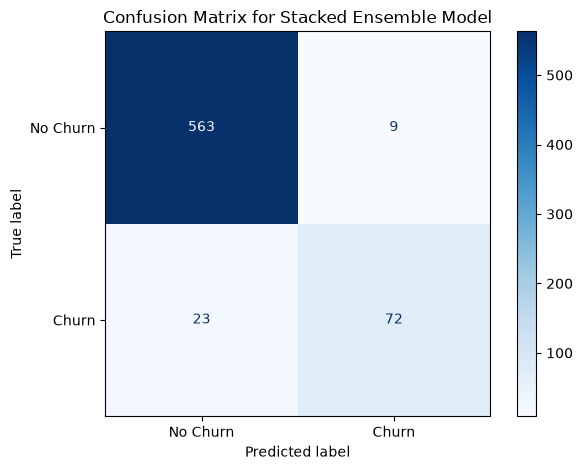

In [12]:
# --- Confusion matrix visualization ---
final_labels = (final_preds >= 0.5).astype(int)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_labels,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d",
)
disp.ax_.set_title("Confusion Matrix for Stacked Ensemble Model")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

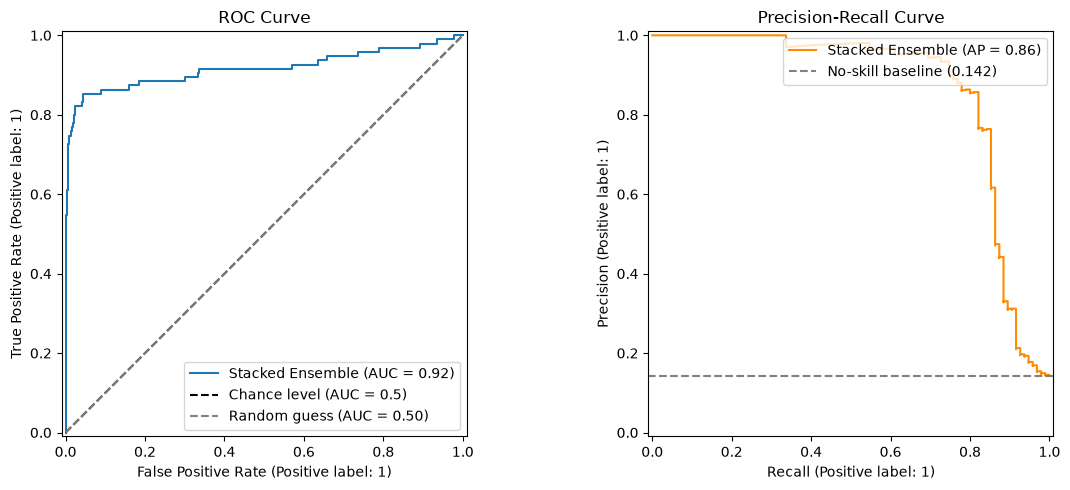

In [13]:
# --- ROC Curve & Precision-Recall Curve ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
roc_disp = RocCurveDisplay.from_predictions(
    y_test, final_preds, name="Stacked Ensemble", ax=axes[0], plot_chance_level=True
)
axes[0].plot(
    [0, 1], [0, 1], "--", color="gray", label="Random guess (AUC = 0.50)"
)
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right")

# Precision-Recall Curve
pr_disp = PrecisionRecallDisplay.from_predictions(
    y_test, final_preds, name="Stacked Ensemble", ax=axes[1]
)
baseline = float(y_test.squeeze().mean())
pr_disp.line_.set_color("darkorange")
axes[1].axhline(
    baseline,
    linestyle="--",
    color="gray",
    label=f"No-skill baseline ({baseline:.3f})"
)
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "performance_curves.png", dpi=150)
plt.show()

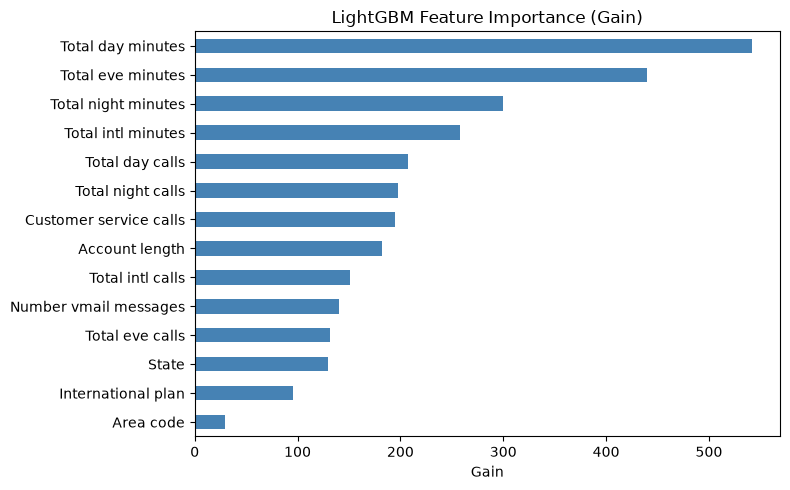

In [14]:
# --- LightGBM feature importance (gain) ---
plt.figure(figsize=(8, 5))
pd.Series(
    final_lgb.feature_importances_, index=X_train_lgb_full.columns
).sort_values().plot(kind="barh", color="steelblue")
plt.xlabel("Gain")
plt.title("LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_gain.png", dpi=150)
plt.show()

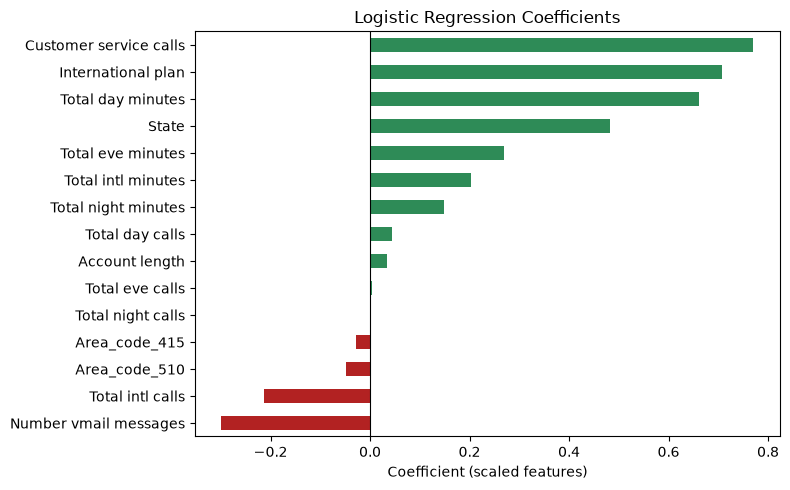

In [15]:
# --- Logistic Regression coefficients ---
plt.figure(figsize=(8, 5))
lr_coefs = pd.Series(
    final_lr.coef_[0], index=X_train_lr_full.columns
).sort_values()
colors = np.where(lr_coefs < 0, "firebrick", "seagreen")

lr_coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (scaled features)")
plt.title("Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lr_coefficients.png", dpi=150)
plt.show()

# Results and Discussion

Model comparison using **PR AUC** and **ROC AUC** scores is presented in the table below:

| Model | ROC-AUC | **PR-AUC** |
|-------|--------|---------|
| LightGBM | 0.9124 | **0.8621** |
| Logistic Regression | 0.8146 | **0.4154** |
| Stacked Ensemble | 0.9158 | **0.8626** |

The table shows that the stacked ensemble model performs better than the individual LightGBM model only by a small margin in terms of ROC AUC and PR AUC scores, indicating that the baseline LightGBM model is already performing well on its own. Our chosen baseline, Logistic Regression, performed significantly worse - underscoring how successful the LightGBM model is in capturing complex patterns in the data. 

With LightGBM being the best performing model, we can see that its PR AUC score of 0.8621 indicate that it is effective in identifying the minority churn class while maintaining high precision. This is perfect in this imbalanced dataset, giving confidence that the model can identify the target class. The ROC AUC score of 0.9124 supplements this information, indicating that the model has a strong ability to discriminate between the churners and non-churners across different threshold values.

### a. Confusion Matrix
![Confusion Matrix](../output/confusion_matrix.png)

Confusion matrix is an evaluation metric that provides information on the model's performance regarding the positive/churn and negative/no churn classes.

1. True Negatives: 563 non-churning customers were correctly predicted as non-churning.
2. True Positives: 72 churning customers were correctly predicted as churning.
3. False Negatives: 23 churning customers were incorrectly predicted as non-churning.
4. False Positives: 9 non-churning customers were incorrectly predicted as churning.

With this information, we can calculate key metrics of the model.

1. **Accuracy**: $\frac{TP+TN}{TP+TN+FP+FN} = 0.9520$ meaning that the stack ensemble model is able to correctly identify 95.2% of the customers that are predicted to churn.
2. **Precision**: $\frac{TP}{TP+FP} = 0.8889$ meaning that 88.9% of the customers predicted to churn actually churned.
3. **Recall**: $\frac{TP}{TP+FN} = 0.7579$ meaning that 75.8% of the customers that should have been predicted to churn were correctly identified by the model.
4. **F1-Score**: $\frac{2 \times Precision \times Recall}{Precision + Recall} = 0.818$

### b. Feature Importance
![Feature Importance](../output/feature_importance_gain.png)

With LightGBM's feature importance plot, we can observe that the most influential features in predicting churn are those related to the customer's usage patterns, such as `total_day_minutes`, `total_eve_minutes`, and `total_night_minutes`. 

To support this observation, the logistic regression coefficient plot below also shows that these customer usage features have significant positive coefficients, indicating that higher values of these features are associated with an increased likelihood of churn. Alongside customer service calls, which also had the highest positive coefficient, these features contributed significantly to the model's predictive power.

![Logistic Regression Coefficients](../output/lr_coefficients.png)

# Conclusion
This machine learning prediction project for telecom customer churn is conducted to address a business problem: identifying customers who are likely to churn, allowing the telecom company to take proactive measures to retain them. The project involved data cleaning, feature engineering, and model training using logistic regression and LightGBM, with a stacked ensemble model being the final choice for prediction.

From the confusion matrix discussed above, it meant that out of 95 customers that will churn, the model identified 72 of them correctly, while 23 were missed. This indicates that the model is effective in identifying churners, but there is still room for improvement in identifying all potential churners that need intervention.

The LightGBM model's feature importance plot and logistic regression coefficient plot provided insights into the most influential features in predicting churn, which are almost all related to customer usage patterns. This suggests that the telecom company should focus on monitoring and analyzing customer usage behavior to identify potential churners. Customer service calls also emerged as a significant predictor of churn, confirming the importance of proactive customer service in preventing churn.